# 📦 Cell 1: Importsts

In [1]:
import os
import time
import torch
import torch.nn as nn
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from tqdm import tqdm
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import scipy.io as sio
import os

# إعدادات أساسية
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {DEVICE}")

🖥️ Device: cuda


In [4]:
import os
MODEL_NAME = 'gaze_resnet_v3'
IMG_SIZE = 224
root        = r'd:\DEPI\CV_projects\Gaze_full_face\MPIIFaceGaze'
test_person = 'p00'

SAVE_DIR = r'D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\checkpoints'

os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ SAVE_DIR: {SAVE_DIR}")

✅ SAVE_DIR: D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\checkpoints


🧠 Cell 2: Model (نسخة محسّنة - أصغر حجماً)

In [5]:
import torch.nn as nn
from torchvision.models import resnet50

class GazeResNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        backbone     = resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.features = nn.Sequential(*list(backbone.children())[:-2])
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.fc       = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),    # ✅ إضافة BatchNorm لتحسين التدريب
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)       # yaw, pitch بالـ Radians
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.fc(x)
        return x


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = GazeResNet(pretrained=True).to(DEVICE)

# اختبار سريع
dummy  = torch.randn(2, 3, 224, 224).to(DEVICE)
out    = model(dummy)
params = sum(p.numel() for p in model.parameters())

print(f"✅ Device     : {DEVICE}")
print(f"✅ Output     : {out.shape}  => [yaw, pitch]")
print(f"📊 Parameters : {params:,} ({params/1e6:.1f}M)")

✅ Device     : cuda
✅ Output     : torch.Size([2, 2])  => [yaw, pitch]
📊 Parameters : 24,559,170 (24.6M)


📂 Cell 3: Dataset (متوافق مع MPIIFaceGaze)

# data normalization

Cell 2: تحميل الـ Calibration

In [6]:


def load_calibration(person_path):
    # Camera intrinsics
    cam_file = sio.loadmat(
        os.path.join(person_path, 'Calibration', 'Camera.mat')
    )
    camera_matrix = cam_file['cameraMatrix']  # 3x3
    dist_coeffs   = cam_file['distCoeffs']    # معاملات التشويه
    
    # Monitor pose (مكان الشاشة في فضاء الكاميرا)
    mon_file = sio.loadmat(
        os.path.join(person_path, 'Calibration', 'monitorPose.mat')
    )
    monitor_rvec = mon_file['rvects']  # دوران الشاشة
    monitor_tvec = mon_file['tvecs']  # موقع الشاشة
    
    return camera_matrix, monitor_rvec, monitor_tvec

In [7]:
def get_normalization_matrix(fc, head_rotation_matrix, camera_matrix,
                              focal_norm=960, distance_norm=600, 
                              roi_size=(224, 224)):
    """
    fc              : مركز الوجه في فضاء الكاميرا (3,)
    head_rotation_matrix : مصفوفة دوران الرأس (3x3)
    focal_norm      : البعد البؤري للكاميرا الافتراضية (بالـ pixels)
    distance_norm   : المسافة الافتراضية للوجه (بالـ mm) = 600mm
    roi_size        : حجم الصورة الناتجة
    """
    
    # ---- 1. بناء الكاميرا الافتراضية المطبّعة ----
    # كاميرا افتراضية بمعاملات ثابتة بغض النظر عن الكاميرا الحقيقية
    camera_norm = np.array([
        [focal_norm, 0,          roi_size[0] / 2],
        [0,          focal_norm, roi_size[1] / 2],
        [0,          0,          1              ]
    ])
    
    # ---- 2. حساب المسافة الحالية للوجه ----
    distance = np.linalg.norm(fc)  # المسافة من الكاميرا للوجه
    
    # ---- 3. محور z الجديد: يشير من الكاميرا للوجه مباشرة ----
    z_axis = fc / distance  # unit vector باتجاه الوجه
    
    # ---- 4. محور y الجديد: للأعلى ----
    head_up = head_rotation_matrix[:, 1]  # العمود الثاني = اتجاه "فوق" الرأس
    y_axis = head_up - np.dot(head_up, z_axis) * z_axis
    y_axis = y_axis / np.linalg.norm(y_axis)
    
    # ---- 5. محور x الجديد: يمين (cross product) ----
    x_axis = np.cross(y_axis, z_axis)
    x_axis = x_axis / np.linalg.norm(x_axis)
    
    # ---- 6. مصفوفة الدوران للـ Normalization ----
    R_norm = np.array([x_axis, y_axis, z_axis])  # 3x3
    
    # ---- 7. مصفوفة تغيير المقياس (لتثبيت المسافة) ----
    S = np.array([
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, distance_norm / distance]  # scale المسافة
    ])
    
    # ---- 8. المصفوفة الكاملة للـ Warping ----
    W = camera_norm @ S @ R_norm @ np.linalg.inv(camera_matrix)
    
    return W, R_norm

In [8]:
def normalize_image(img, W, roi_size=(224, 224)):
    """
    تحويل الصورة الأصلية للصورة المطبّعة
    """
    img_normalized = cv2.warpPerspective(img, W, roi_size)
    return img_normalized

In [9]:
def normalize_gaze(gaze_vec, R_norm):
    """
    المهم جداً: لازم تدوّر متجه النظر
    بنفس مصفوفة التدوير اللي دوّرت بيها الصورة!
    """
    gaze_normalized = R_norm @ gaze_vec
    gaze_normalized = gaze_normalized / np.linalg.norm(gaze_normalized)
    
    # حساب الزوايا من المتجه المطبّع
    yaw   = np.arctan2(-gaze_normalized[0], -gaze_normalized[2])
    pitch = np.arcsin(-gaze_normalized[1])
    
    return gaze_normalized, yaw, pitch

In [10]:
def process_sample(img_path, fc, gt, head_rvec, camera_matrix):
    """
    Pipeline كاملة لـ sample واحد
    """
    # تحميل الصورة
    img = cv2.imread(img_path)
    
    # تحويل rotation vector لـ matrix
    head_rotation_matrix, _ = cv2.Rodrigues(head_rvec)
    
    # gaze vector خام
    gaze_vec = gt - fc
    gaze_vec = gaze_vec / np.linalg.norm(gaze_vec)
    
    # حساب مصفوفة الـ Normalization
    W, R_norm = get_normalization_matrix(
        fc, head_rotation_matrix, camera_matrix,
        focal_norm=960,
        distance_norm=600,
        roi_size=(224, 224)
    )
    
    # تطبيق الـ Warping على الصورة
    img_normalized = normalize_image(img, W, roi_size=(224, 224))
    
    # تعديل الـ Gaze بنفس التدوير
    gaze_norm, yaw, pitch = normalize_gaze(gaze_vec, R_norm)
    
    return img_normalized, yaw, pitch,gaze_norm

In [11]:


train_data  = []
test_data   = []

for i in range(15):
    p   = f'p{i:02d}'
    ann = os.path.join(root, p, f'{p}.txt')
    if not os.path.exists(ann):
        continue

    camera_matrix, _, _ = load_calibration(os.path.join(root, p))

    with open(ann, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 28:
                continue

            img_path  = os.path.join(root, p, parts[0])
            eye       = parts[27]

            fc        = np.array([float(parts[21]), float(parts[22]), float(parts[23])])
            gt        = np.array([float(parts[24]), float(parts[25]), float(parts[26])])
            head_rvec = np.array([float(parts[15]), float(parts[16]), float(parts[17])])

            sample = {
                'path'      : img_path,
                'person'    : p,
                'eye'       : eye,
                'fc'        : fc,
                'gt'        : gt,
                'head_rvec' : head_rvec,
                'cam_mat'   : camera_matrix,
            }

            if p == test_person:
                test_data.append(sample)
            else:
                train_data.append(sample)

print(f'✅ Train: {len(train_data)} samples')
print(f'✅ Test:  {len(test_data)} samples ({test_person})')

✅ Train: 34740 samples
✅ Test:  2927 samples (p00)


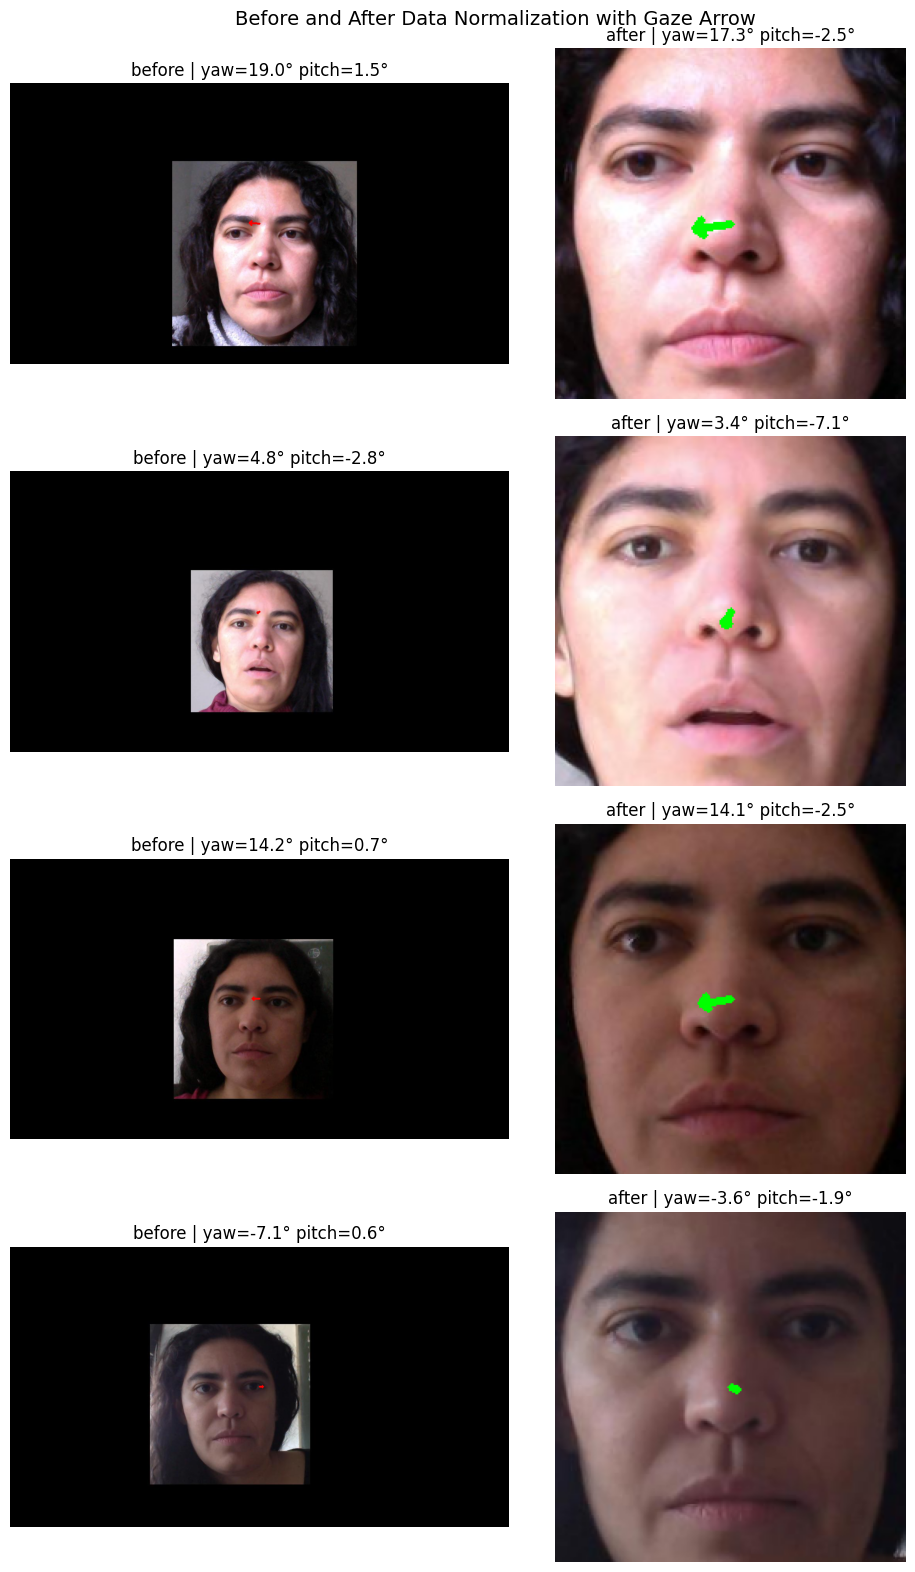

In [12]:
def draw_gaze_on_image(img, gaze_vec_2d, color=(0, 255, 0)):
    """
    ارسم سهم الـ gaze من مركز الصورة
    gaze_vec_2d: (yaw, pitch) بالـ radians
    """
    img_draw = img.copy()
    h, w     = img_draw.shape[:2]
    cx, cy   = w // 2, h // 2        # مركز الصورة

    arrow_len = 80
    yaw, pitch = gaze_vec_2d

    # تحويل الزاوية لاتجاه السهم على الصورة
    dx = int(-arrow_len * np.sin(yaw))
    dy = int(-arrow_len * np.sin(pitch))

    cv2.arrowedLine(img_draw,
                    (cx, cy),
                    (cx + dx, cy + dy),
                    color, 3, tipLength=0.3)
    return img_draw


# ---- اختار عدد عشوائي من الـ samples للعرض ----
num_show = 4
indices  = np.random.choice(len(test_data), num_show, replace=False)

fig, axes = plt.subplots(num_show, 2, figsize=(10, num_show * 4))
fig.suptitle('Before and After Data Normalization with Gaze Arrow', fontsize=14)

for row, idx in enumerate(indices):
    s = test_data[idx]

    # ---- الصورة الأصلية ----
    img_orig = cv2.imread(s['path'])
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

    # gaze على الصورة الأصلية (من الـ raw vector)
    gaze_raw = s['gt'] - s['fc']
    gaze_raw = gaze_raw / np.linalg.norm(gaze_raw)
    yaw_raw   = np.arctan2(-gaze_raw[0], -gaze_raw[2])
    pitch_raw = np.arcsin(-gaze_raw[1])
    img_orig_arrow = draw_gaze_on_image(img_orig, (yaw_raw, pitch_raw), color=(255, 0, 0))

    # ---- الصورة بعد Normalization ----
    img_norm, yaw_n, pitch_n, _ = process_sample(
        s['path'], s['fc'], s['gt'], s['head_rvec'], s['cam_mat']
    )
    img_norm_rgb   = cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB)
    img_norm_arrow = draw_gaze_on_image(img_norm_rgb, (yaw_n, pitch_n), color=(0, 255, 0))

    # ---- العرض ----
    axes[row, 0].imshow(img_orig_arrow)
    axes[row, 0].set_title(f'before | yaw={np.degrees(yaw_raw):.1f}° pitch={np.degrees(pitch_raw):.1f}°')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_norm_arrow)
    axes[row, 1].set_title(f'after | yaw={np.degrees(yaw_n):.1f}° pitch={np.degrees(pitch_n):.1f}°')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

📂 Cell 4: Dataset Class & DataLoaders

In [13]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class GazeDataset(Dataset):
    def __init__(self, samples, img_size=224, augment=False):
        self.samples  = samples
        self.img_size = img_size
        self.augment  = augment
        
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # ✅ تطبيق Data Normalization على الصورة والـ Gaze
        img_norm, yaw, pitch, _ = process_sample(
            s['path'], s['fc'], s['gt'],
            s['head_rvec'], s['cam_mat']
        )

        # تحويل BGR -> RGB وـ Resize
        img = cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # ✅ Augmentation بدون تعديل الـ original data
        flip = False
        if self.augment:
            # Horizontal Flip
            if np.random.random() > 0.5:
                img  = cv2.flip(img, 1)
                flip = True   # نحفظ القرار ونطبقه على الـ yaw

            # Color Jitter
            if np.random.random() > 0.5:
                factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)

        # تحويل لـ Tensor + Normalize
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = self.normalize(img)

        # ✅ تطبيق الـ flip على الـ yaw بعد ما عرفنا القرار
        if flip:
            yaw = -yaw

        # ✅ الـ Radians أفضل للتدريب (قيم بين -π و π)
        gaze = torch.tensor([yaw, pitch], dtype=torch.float32)

        return img, gaze

In [14]:
BATCH    = 32
IMG_SIZE = 224

train_split, val_split = train_test_split(
    train_data, test_size=0.2, random_state=42
)

train_set = GazeDataset(train_split, img_size=IMG_SIZE, augment=True)
val_set   = GazeDataset(val_split,   img_size=IMG_SIZE, augment=False)
test_set  = GazeDataset(test_data,   img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'✅ Train : {len(train_set):,} samples')
print(f'✅ Val   : {len(val_set):,} samples')
print(f'✅ Test  : {len(test_set):,} samples')

# ✅ اختبار batch
imgs, gazes = next(iter(train_loader))
print(f'\n📦 Batch  : imgs={imgs.shape}  gazes={gazes.shape}')
print(f'📊 Gaze range (rad): [{gazes.min():.3f}, {gazes.max():.3f}]')
print(f'📊 Gaze range (deg): [{gazes.min().item()*57.3:.1f}°, {gazes.max().item()*57.3:.1f}°]')

✅ Train : 27,792 samples
✅ Val   : 6,948 samples
✅ Test  : 2,927 samples

📦 Batch  : imgs=torch.Size([32, 3, 224, 224])  gazes=torch.Size([32, 2])
📊 Gaze range (rad): [-0.436, 0.329]
📊 Gaze range (deg): [-25.0°, 18.9°]


Cell 1 — Angular Error Loss + Training Setup

In [15]:
# ─────────────────────────────────────────────────────────
# ✅ التغيير الوحيد: criterion بقى Angular Error Loss
# ─────────────────────────────────────────────────────────
RAD2DEG = 180.0 / np.pi

class AngularErrorLoss(nn.Module):
    """
    Loss = متوسط الزاوية بين متجه النظر المتوقع والحقيقي
    المخرج بالـ Radians علشان الـ backprop يشتغل صح
    """
    def forward(self, pred, target):
        def to_vec(t):
            yaw, pitch = t[:, 0], t[:, 1]
            x = -torch.cos(pitch) * torch.sin(yaw)
            y = -torch.sin(pitch)
            z = -torch.cos(pitch) * torch.cos(yaw)
            return torch.stack([x, y, z], dim=1)          # (N, 3)

        v_p = to_vec(pred)
        v_t = to_vec(target)

        cos = (v_p * v_t).sum(dim=1).clamp(-1.0, 1.0)
        return torch.acos(cos).mean()                      # Radians


# ── Setup ────────────────────────────────────────────────
model = GazeResNet(pretrained=True).to(DEVICE)

for param in model.features.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5, verbose=True
)

criterion = AngularErrorLoss()          # ✅ التغيير الوحيد هنا

# ── History: مفتاح واحد بدل 4 ───────────────────────────
history = {
    'train_ang' : [],                   # ← بالدرجات للقراءة
    'val_ang'   : [],
}

best_val_ang   = float('inf')
UNFREEZE_EPOCH = 5

print(f"✅ Device          : {DEVICE}")
print(f"✅ Criterion       : AngularErrorLoss")
print(f"📊 Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"🔒 Backbone frozen until epoch {UNFREEZE_EPOCH}")

✅ Device          : cuda
✅ Criterion       : AngularErrorLoss
📊 Trainable params: 1,051,138
🔒 Backbone frozen until epoch 5


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Cell 2 — train_epoch و validate

In [14]:
# ─────────────────────────────────────────────────────────
# ✅ التغيير: شريط تقدم أوضح مع epoch + angular error
# ─────────────────────────────────────────────────────────

def train_epoch(model, loader, criterion, optimizer, device, epoch, total_epochs):
    model.train()
    total_ang     = 0.0
    running_ang   = 0.0      # متوسط متحرك للعرض

    pbar = tqdm(
        loader,
        desc=f"🔵 Train [{epoch:02d}/{total_epochs}]",
        leave=True,
        ncols=100,
        colour='blue'
    )

    for batch_idx, (imgs, gazes) in enumerate(pbar, 1):
        imgs, gazes = imgs.to(device), gazes.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, gazes)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        ang_deg     = loss.item() * RAD2DEG
        total_ang  += ang_deg * imgs.size(0)
        running_ang = total_ang / (batch_idx * loader.batch_size)   # تقريبي

        pbar.set_postfix(ordered_dict={
            "Ang°"     : f"{ang_deg:.2f}",
            "Avg°"     : f"{running_ang:.2f}",
            "LR"       : f"{optimizer.param_groups[0]['lr']:.0e}",
        })

    return total_ang / len(loader.dataset)


def validate(model, loader, criterion, device, epoch, total_epochs):
    model.eval()
    total_ang = 0.0

    pbar = tqdm(
        loader,
        desc=f"🟡 Val   [{epoch:02d}/{total_epochs}]",
        leave=True,
        ncols=100,
        colour='yellow'
    )

    with torch.no_grad():
        for batch_idx, (imgs, gazes) in enumerate(pbar, 1):
            imgs, gazes = imgs.to(device), gazes.to(device)
            preds = model(imgs)
            loss  = criterion(preds, gazes)

            ang_deg    = loss.item() * RAD2DEG
            total_ang += ang_deg * imgs.size(0)
            avg_ang    = total_ang / (batch_idx * loader.batch_size)

            pbar.set_postfix(ordered_dict={
                "Ang°" : f"{ang_deg:.2f}",
                "Avg°" : f"{avg_ang:.2f}",
            })

    return total_ang / len(loader.dataset)

print("✅ دوال التدريب جاهزة")

✅ دوال التدريب جاهزة


In [15]:
# ─────────────────────────────────────────────────────────
# Cell Diagnostic: اكتشف من فين الـ NaN
# ─────────────────────────────────────────────────────────
def check_data_for_nan(loader, num_batches=10):
    nan_imgs, nan_gazes, total = 0, 0, 0

    for i, (imgs, gazes) in enumerate(loader):
        if i >= num_batches:
            break
        total += imgs.size(0)
        nan_imgs  += torch.isnan(imgs).any(dim=[1,2,3]).sum().item()
        nan_gazes += torch.isnan(gazes).any(dim=1).sum().item()

    print(f"📦 Checked {total} samples from first {num_batches} batches")
    print(f"{'❌' if nan_imgs  > 0 else '✅'} NaN in images : {nan_imgs}")
    print(f"{'❌' if nan_gazes > 0 else '✅'} NaN in gazes  : {nan_gazes}")

    if nan_gazes > 0:
        print("\n⚠️  السبب الرئيسي: normalize_gaze بترجع NaN")
        print("   → np.arcsin() اتاخد قيمة برة نطاق [-1, 1]")
    if nan_imgs > 0:
        print("\n⚠️  في مشكلة في الصور نفسها")

check_data_for_nan(train_loader)

📦 Checked 320 samples from first 10 batches
✅ NaN in images : 0
✅ NaN in gazes  : 0


In [16]:
# ─────────────────────────────────────────────────────────
# Cell Fix 1: إصلاح normalize_gaze
# السبب: بعد R_norm @ gaze_vec المتجه بيبقى مش unit vector
# بالظبط بسبب floating point → arcsin بيرجع NaN
# ─────────────────────────────────────────────────────────
def normalize_gaze(gaze_vec, R_norm):
    gaze_normalized = R_norm @ gaze_vec
    gaze_normalized = gaze_normalized / np.linalg.norm(gaze_normalized)

    # ✅ الإضافة الوحيدة: clip قبل arcsin علشان تتجنب NaN
    val   = np.clip(-gaze_normalized[1], -1.0, 1.0)
    pitch = np.arcsin(val)
    yaw   = np.arctan2(-gaze_normalized[0], -gaze_normalized[2])

    return gaze_normalized, yaw, pitch

In [17]:
# ─────────────────────────────────────────────────────────
# Cell Fix 2: فلتر NaN في الـ Dataset كـ safety net
# ─────────────────────────────────────────────────────────
class GazeDataset(Dataset):
    def __init__(self, samples, img_size=224, augment=False):
        self.img_size  = img_size
        self.augment   = augment
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
        # ✅ فلتر الـ samples اللي بترجع NaN قبل التدريب
        self.samples = self._filter_nan(samples)

    def _filter_nan(self, samples):
        clean = []
        nan_count = 0
        for s in samples:
            try:
                _, yaw, pitch, _ = process_sample(
                    s['path'], s['fc'], s['gt'],
                    s['head_rvec'], s['cam_mat']
                )
                if np.isnan(yaw) or np.isnan(pitch):
                    nan_count += 1
                else:
                    clean.append(s)
            except Exception:
                nan_count += 1

        if nan_count > 0:
            print(f"⚠️  Filtered {nan_count} NaN samples out of {len(samples)}")
        return clean

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        img_norm, yaw, pitch, _ = process_sample(
            s['path'], s['fc'], s['gt'],
            s['head_rvec'], s['cam_mat']
        )

        img = cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        flip = False
        if self.augment:
            if np.random.random() > 0.5:
                img  = cv2.flip(img, 1)
                flip = True
            if np.random.random() > 0.5:
                factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)

        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = self.normalize(img)

        if flip:
            yaw = -yaw

        gaze = torch.tensor([yaw, pitch], dtype=torch.float32)
        return img, gaze

In [16]:
# ─────────────────────────────────────────────────────────
# Cell Fix 3: Loss مستقرة عددياً
# المشكلة: gradient بتاع acos عند cos=±1 هو ±inf
# الحل: clamp بـ eps بدل 1.0 بالظبط
# ─────────────────────────────────────────────────────────
class AngularErrorLoss(nn.Module):

    def forward(self, pred, target):
        v_p = self._to_vec(pred)
        v_t = self._to_vec(target)

        cos = (v_p * v_t).sum(dim=1)

        # ✅ eps=1e-6 يمنع gradient explosion عند cos = ±1
        # بدلاً من clamp(-1, 1) اللي بيخلي gradient = inf
        cos = cos.clamp(-1.0 + 1e-6, 1.0 - 1e-6)

        return torch.acos(cos).mean()          # Radians

    @staticmethod
    def _to_vec(t):
        yaw, pitch = t[:, 0], t[:, 1]
        x = -torch.cos(pitch) * torch.sin(yaw)
        y = -torch.sin(pitch)
        z = -torch.cos(pitch) * torch.cos(yaw)
        return torch.stack([x, y, z], dim=1)  # (N, 3) unit vectors

Cell 3 — Resume

In [23]:
print(len(optimizer.param_groups))
print(len(ckpt['opt_state']['param_groups']))

1
3


In [28]:
# ─────────────────────────────────────────────────────────
# ✅ Resume Training Safely
# ─────────────────────────────────────────────────────────
LOAD_PATH   = os.path.join(SAVE_DIR, f'{MODEL_NAME}_best.pth')
start_epoch = 0

if os.path.exists(LOAD_PATH):

    ckpt = torch.load(
        LOAD_PATH,
        map_location=DEVICE,
        weights_only=False
    )

    # ── Load model weights ───────────────────────────────
    model.load_state_dict(ckpt['model_state'])

    # ── Load optimizer safely ────────────────────────────
    if 'opt_state' in ckpt:
        try:
            optimizer.load_state_dict(ckpt['opt_state'])
            print("✅ Optimizer state loaded")
        except ValueError:
            print("⚠️ Optimizer state skipped (parameter groups mismatch)")

    # ── Resume info ──────────────────────────────────────
    start_epoch = ckpt.get('epoch', 0)

    # history fallback
    history = ckpt.get('history', {})

    if 'train_ang' not in history:
        history['train_ang'] = []

    if 'val_ang' not in history:
        history['val_ang'] = []

    # best validation angular error
    if 'best_val_ang' in ckpt:
        best_val_ang = ckpt['best_val_ang']
    else:
        best_val_ang = (
            min(history['val_ang'])
            if len(history['val_ang']) > 0
            else float('inf')
        )

    print(f"✅ Resumed from epoch {start_epoch}")
    print(f"📊 Best Val Angular Error: {best_val_ang:.2f}°")

else:

    history = {
        'train_ang': [],
        'val_ang': []
    }

    best_val_ang = float('inf')

    print("⚠️ No checkpoint found, starting fresh")

✅ Optimizer state loaded
✅ Resumed from epoch 20
📊 Best Val Angular Error: 1.76°


Cell 4 — Training Loop

In [22]:
# ─────────────────────────────────────────────────────────
# ✅ التغيير: print + history + حفظ بناءً على Angular Error
# ─────────────────────────────────────────────────────────
import time

EPOCHS         = 20
UNFREEZE_EPOCH = 5
best_val_ang   = min(history['val_ang']) if history['val_ang'] else float('inf')


# 🟢 1. التأكد إن الكود عارف هو هيبدأ منين (عشان يكمل تدريب أو يبدأ من الصفر)
if 'start_epoch' not in locals():
    start_epoch = 0

if 'best_val_ang' not in locals() or start_epoch == 0:
    best_val_ang = float('inf')

print(f"🚀 Starting training from Epoch {start_epoch + 1} ...")

# 🟢 2. العداد دلوقتي بيبدأ من بعد آخر Epoch الموديل وقف عنده

# ✅ التغيير الوحيد: range بيبدأ من start_epoch
for epoch in range(start_epoch + 1, start_epoch + EPOCHS + 1):
    

    if epoch == UNFREEZE_EPOCH + 1:
        print("\n🔓 Unfreezing backbone with lower LR...")
        for param in model.features.parameters():
            param.requires_grad = True

        optimizer = torch.optim.Adam([
            {'params': model.features.parameters(), 'lr': 1e-5},
            {'params': model.pool.parameters(),     'lr': 1e-4},
            {'params': model.fc.parameters(),       'lr': 1e-4},
        ])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=3, factor=0.5, verbose=True
        )

    t0 = time.time()


    train_ang = train_epoch(model, train_loader, criterion,
                        optimizer, DEVICE, epoch, EPOCHS)   # ← أضف epoch, EPOCHS

    val_ang   = validate(model, val_loader, criterion,
                     DEVICE, epoch, EPOCHS)                 # ← أضف epoch, EPOCHS

    # ✅ Scheduler بيشتغل على Angular Error (بالدرجات)
    scheduler.step(val_ang)

    history['train_ang'].append(train_ang)
    history['val_ang'].append(val_ang)

    saved = ''
    if val_ang < best_val_ang:
        best_val_ang = val_ang
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'opt_state'  : optimizer.state_dict(),
            'history'    : history,
            'best_val_ang': best_val_ang,          # ✅ اسم واضح
        }, os.path.join(SAVE_DIR, f'{MODEL_NAME}_best.pth'))
        saved = '  💾 SAVED'

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Angular Error  Train: {train_ang:.2f}°  Val: {val_ang:.2f}° | "
        f"{time.time()-t0:.0f}s{saved}"
    )

torch.save({
    'epoch'      : EPOCHS,
    'model_state': model.state_dict(),
    'opt_state'  : optimizer.state_dict(),
    'history'    : history,
}, os.path.join(SAVE_DIR, f'{MODEL_NAME}_last.pth'))

print(f"\n🏆 Best Val Angular Error : {best_val_ang:.2f}°")

🚀 Starting training from Epoch 1 ...


🟡 Val   [01/20]: 100%|█████████████████████| 218/218 [00:54<00:00,  3.98it/s, Ang°=1.95, Avg°=2.10]


Epoch 01/20 | Angular Error  Train: 2.17°  Val: 2.11° | 442s  💾 SAVED


🟡 Val   [02/20]: 100%|█████████████████████| 218/218 [00:48<00:00,  4.47it/s, Ang°=1.97, Avg°=2.14]


Epoch 02/20 | Angular Error  Train: 2.19°  Val: 2.15° | 393s


...

Epoch 18/20 | Angular Error  Train: 1.73°  Val: 1.80° | 377s  💾 SAVED


🟡 Val   [19/20]: 100%|█████████████████████| 218/218 [00:45<00:00,  4.75it/s, Ang°=2.14, Avg°=1.83]


Epoch 19/20 | Angular Error  Train: 1.70°  Val: 1.83° | 376s


🟡 Val   [20/20]: 100%|█████████████████████| 218/218 [00:45<00:00,  4.75it/s, Ang°=1.60, Avg°=1.75]


Epoch 20/20 | Angular Error  Train: 1.65°  Val: 1.76° | 377s  💾 SAVED

🏆 Best Val Angular Error : 1.76°


In [32]:
# ─────────────────────────────────────────────────────────
# ✅ Load old model for fine-tuning
# ─────────────────────────────────────────────────────────

OLD_MODEL_PATH = r'D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\checkpoints\gaze_resnet_v3_best.pth'

model = GazeResNet(pretrained=False).to(DEVICE)

# ── Load checkpoint ─────────────────────────────────────
ckpt = torch.load(
    OLD_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(ckpt['model_state'])

print(f"✅ Old model loaded from epoch : {ckpt.get('epoch', 'N/A')}")

# ── Restore history correctly ───────────────────────────
history = ckpt.get('history', {})

if 'train_ang' not in history:
    history['train_ang'] = []

if 'val_ang' not in history:
    history['val_ang'] = []

# ── Restore best metric ─────────────────────────────────
if len(history['val_ang']) > 0:
    best_val_ang = min(history['val_ang'])
    print(f"📊 Old best val angular error : {best_val_ang:.4f}°")
else:
    best_val_ang = float('inf')
    print("⚠️ No old validation history found")

# ── Resume epoch count ──────────────────────────────────
start_epoch = ckpt.get('epoch', 0)

# ─────────────────────────────────────────────────────────
# ✅ Fine-tuning setup
# ─────────────────────────────────────────────────────────

criterion = AngularErrorLoss()

optimizer = torch.optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.pool.parameters(),     'lr': 1e-4},
    {'params': model.fc.parameters(),       'lr': 1e-4},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
    verbose=True
)

print(f"\n✅ Fine-tuning with Angular Error Loss")
print(f"📊 Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"🚀 Resuming from epoch {start_epoch + 1}")

✅ Old model loaded from epoch : 20
📊 Old best val angular error : 1.7620°

✅ Fine-tuning with Angular Error Loss
📊 Trainable params: 24,559,170
🚀 Resuming from epoch 21


Cell 5 — History Plots

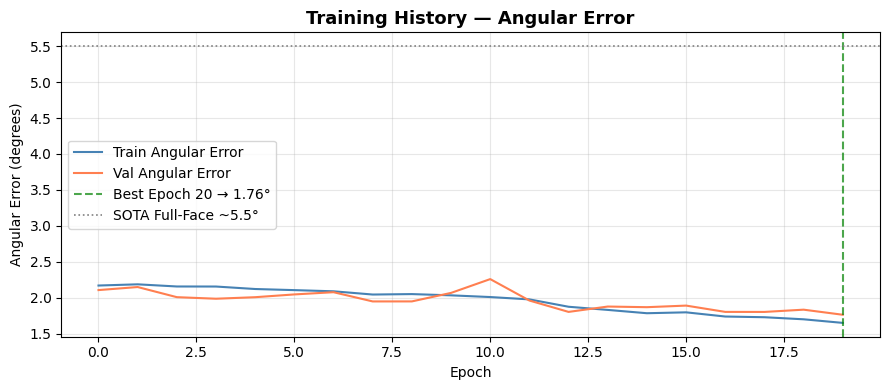


📊 Best Val Angular Error : 1.76° (Epoch 20)
📊 Final Val Angular Error: 1.76°
💾 History plot saved to:
D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\checkpoints\gaze_resnet_v3_history.png


In [33]:
# ─────────────────────────────────────────────────────────
# ✅ Plot Angular Error History Safely
# ─────────────────────────────────────────────────────────

# تأكد إن فيه بيانات
if len(history.get('train_ang', [])) == 0 or len(history.get('val_ang', [])) == 0:

    print("⚠️ No training history found to plot.")

else:

    fig, ax = plt.subplots(figsize=(9, 4))

    # ── Plot curves ──────────────────────────────────────
    ax.plot(
        history['train_ang'],
        label='Train Angular Error',
        color='steelblue'
    )

    ax.plot(
        history['val_ang'],
        label='Val Angular Error',
        color='coral'
    )

    # ── Best epoch ───────────────────────────────────────
    best_epoch = int(np.argmin(history['val_ang']))
    best_val   = float(np.min(history['val_ang']))

    ax.axvline(
        best_epoch,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f"Best Epoch {best_epoch + 1} → {best_val:.2f}°"
    )

    # ── Reference line ───────────────────────────────────
    ax.axhline(
        5.5,
        color='gray',
        linestyle=':',
        lw=1.2,
        label='SOTA Full-Face ~5.5°'
    )

    # ── Labels ───────────────────────────────────────────
    ax.set_title(
        'Training History — Angular Error',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Angular Error (degrees)')

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    # ── Save figure ──────────────────────────────────────
    save_path = os.path.join(
        SAVE_DIR,
        f'{MODEL_NAME}_history.png'
    )

    plt.savefig(save_path, dpi=150)

    plt.show()

    # ── Print results ────────────────────────────────────
    print(f"\n📊 Best Val Angular Error : {best_val:.2f}° (Epoch {best_epoch + 1})")

    print(f"📊 Final Val Angular Error: {history['val_ang'][-1]:.2f}°")

    print(f"💾 History plot saved to:\n{save_path}")

🧪 Cell 10: Test على الـ Validation Set

🧪 Testing on: p00


Testing: 100%|██████████| 92/92 [00:23<00:00,  3.92it/s]



  📊  TEST RESULTS — p00
  Samples                : 2927
  ───────────────────────────────────────────────────
  ✅ Mean Angular Error  : 2.47° ± 1.53°
  ✅ Median Ang. Error   : 2.27°
  ✅ Max Angular Error   : 20.58°
  ───────────────────────────────────────────────────
  MAE Yaw   (ref)        : 1.72° ± 1.36°
  MAE Pitch (ref)        : 1.48° ± 1.26°

📚 MPII Benchmarks:
  • Full Face methods    ~ 4.0° – 5.5°
  • Eye-only methods     ~ 5.5° – 7.0°


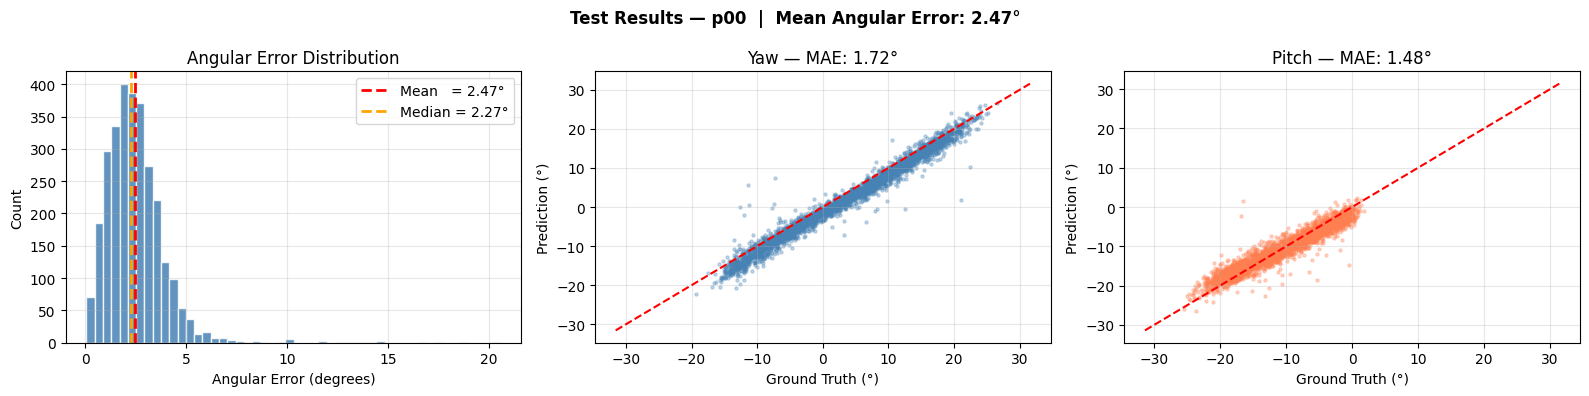

In [34]:
# ─────────────────────────────────────────────────────────
# Test Cell — Angular Error + MAE Reference
# ─────────────────────────────────────────────────────────
RAD2DEG = 180.0 / np.pi

def to_gaze_vector(yaw_rad, pitch_rad):
    x = -np.cos(pitch_rad) * np.sin(yaw_rad)
    y = -np.sin(pitch_rad)
    z = -np.cos(pitch_rad) * np.cos(yaw_rad)
    return np.stack([x, y, z], axis=1)

def compute_angular_error(preds_rad, labels_rad):
    v_pred  = to_gaze_vector(preds_rad[:, 0],  preds_rad[:, 1])
    v_true  = to_gaze_vector(labels_rad[:, 0], labels_rad[:, 1])
    cos_sim = np.einsum('ij,ij->i', v_pred, v_true)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    return np.degrees(np.arccos(cos_sim))

# ════════════════════════════════════════════════════════
print(f"🧪 Testing on: {test_person}")
print("=" * 55)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, gazes in tqdm(test_loader, desc='Testing'):
        imgs   = imgs.to(DEVICE)
        preds  = model(imgs).cpu().numpy()
        labels = gazes.numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

all_preds  = np.array(all_preds)    # (N, 2) Radians
all_labels = np.array(all_labels)   # (N, 2) Radians

# ── حساب المقاييس ─────────────────────────────────────
angular_errors = compute_angular_error(all_preds, all_labels)

all_preds_deg  = all_preds  * RAD2DEG
all_labels_deg = all_labels * RAD2DEG
mae_errors     = np.abs(all_preds_deg - all_labels_deg)

# ── النتائج ───────────────────────────────────────────
print("\n" + "=" * 55)
print(f"  📊  TEST RESULTS — {test_person}")
print("=" * 55)
print(f"  Samples                : {len(all_preds)}")
print(f"  {'─'*51}")
print(f"  ✅ Mean Angular Error  : {angular_errors.mean():.2f}° ± {angular_errors.std():.2f}°")
print(f"  ✅ Median Ang. Error   : {np.median(angular_errors):.2f}°")
print(f"  ✅ Max Angular Error   : {angular_errors.max():.2f}°")
print(f"  {'─'*51}")
print(f"  MAE Yaw   (ref)        : {mae_errors[:, 0].mean():.2f}° ± {mae_errors[:, 0].std():.2f}°")
print(f"  MAE Pitch (ref)        : {mae_errors[:, 1].mean():.2f}° ± {mae_errors[:, 1].std():.2f}°")
print("=" * 55)
print(f"\n📚 MPII Benchmarks:")
print(f"  • Full Face methods    ~ 4.0° – 5.5°")
print(f"  • Eye-only methods     ~ 5.5° – 7.0°")

# ════════════════════════════════════════════════════════
# Plots
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── (1) Angular Error Distribution ───────────────────
axes[0].hist(angular_errors, bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(angular_errors.mean(),
                color='red',    linestyle='--', lw=2,
                label=f"Mean   = {angular_errors.mean():.2f}°")
axes[0].axvline(np.median(angular_errors),
                color='orange', linestyle='--', lw=2,
                label=f"Median = {np.median(angular_errors):.2f}°")
axes[0].set_xlabel('Angular Error (degrees)')
axes[0].set_ylabel('Count')
axes[0].set_title('Angular Error Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── (2) Scatter Yaw ───────────────────────────────────
lim_y = max(abs(all_labels_deg[:, 0]).max(),
            abs(all_preds_deg[:, 0]).max()) + 5
axes[1].scatter(all_labels_deg[:, 0], all_preds_deg[:, 0],
                alpha=0.3, s=5, color='steelblue')
axes[1].plot([-lim_y, lim_y], [-lim_y, lim_y], 'r--', lw=1.5)
axes[1].set_xlabel('Ground Truth (°)')
axes[1].set_ylabel('Prediction (°)')
axes[1].set_title(f'Yaw — MAE: {mae_errors[:, 0].mean():.2f}°')
axes[1].grid(alpha=0.3)

# ── (3) Scatter Pitch ─────────────────────────────────
lim_p = max(abs(all_labels_deg[:, 1]).max(),
            abs(all_preds_deg[:, 1]).max()) + 5
axes[2].scatter(all_labels_deg[:, 1], all_preds_deg[:, 1],
                alpha=0.3, s=5, color='coral')
axes[2].plot([-lim_p, lim_p], [-lim_p, lim_p], 'r--', lw=1.5)
axes[2].set_xlabel('Ground Truth (°)')
axes[2].set_ylabel('Prediction (°)')
axes[2].set_title(f'Pitch — MAE: {mae_errors[:, 1].mean():.2f}°')
axes[2].grid(alpha=0.3)

plt.suptitle(
    f'Test Results — {test_person}  |  '
    f'Mean Angular Error: {angular_errors.mean():.2f}°',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f'{MODEL_NAME}_test_{test_person}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

📹 Cell 11: Live Camera Demo

In [35]:
import os, cv2, time, torch, random, numpy as np
from collections import deque
from screeninfo import get_monitors
import torchvision.transforms as transforms

RAD2DEG = 180.0 / np.pi

# ---------- شاشة ----------
try:
    mon = get_monitors()[0]
    SCREEN_W, SCREEN_H = mon.width, mon.height
except:
    SCREEN_W, SCREEN_H = 1920, 1080

# ---------- تحميل الموديل ----------
MODEL_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.pth")
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Model loaded from {MODEL_PATH}")

# ---------- Normalize نفس التدريب ----------
INFER_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),                                        # [0,1]
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess_face(face_bgr, img_size):
    """نفس pipeline التدريب بالظبط"""
    img = cv2.resize(face_bgr, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # ✅ BGR->RGB زي التدريب
    tensor = INFER_TRANSFORM(img)                   # ✅ ToTensor + Normalize
    return tensor.unsqueeze(0).to(DEVICE)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12896\3137429596.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_PATH, map_location=DEVICE)


✅ Model loaded from D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\checkpoints\gaze_resnet_v3_best.pth


# after smotting 

In [36]:
import time, os, cv2, random
import numpy as np
import torch
from collections import deque

RAD2DEG = 180.0 / np.pi
MARGIN  = 140

class GazeCalibrator:
    def __init__(self, sw, sh):
        self.sw, self.sh  = sw, sh
        self.ref_yaw      = 0.0
        self.ref_pitch    = 0.0
        self.calibrated   = False
        self.invert_x     = True
        self.invert_y     = False
        self.scale_x      = sw / 1.2
        self.scale_y      = sh / 0.8
        self.calib_points = []

    def add_calib_point(self, sx, sy, samples):
        if not samples:
            return
        yaw   = float(np.mean([s[0] for s in samples]))
        pitch = float(np.mean([s[1] for s in samples]))
        self.calib_points.append((sx, sy, yaw, pitch))
        if len(self.calib_points) == 1:
            self.ref_yaw   = yaw
            self.ref_pitch = pitch
            self.calibrated = True
            print(f"✅ CENTER: yaw={yaw*RAD2DEG:.1f}°  pitch={pitch*RAD2DEG:.1f}°")
        else:
            print(f"✅ Pt{len(self.calib_points)}: "
                  f"yaw={yaw*RAD2DEG:.1f}°  pitch={pitch*RAD2DEG:.1f}°")

    def compute_scale(self):
        if len(self.calib_points) < 2:
            return
        ref, sx_list, sy_list = self.calib_points[0], [], []

        for pt in self.calib_points[1:]:
            dx, dy     = pt[0]-ref[0], pt[1]-ref[1]
            dyaw       = -(pt[2]-ref[2]) if self.invert_x else (pt[2]-ref[2])
            dpitch     = pt[3]-ref[3]
            if abs(dyaw)   > 0.02: sx_list.append(abs(dx/dyaw))
            if abs(dpitch) > 0.02: sy_list.append(abs(dy/dpitch))

        DAMPING = 0.60
        self.scale_x = min(float(np.median(sx_list))*DAMPING, 3500.0) \
                       if sx_list else 2500.0
        self.scale_y = min(float(np.median(sy_list))*DAMPING, 2800.0) \
                       if sy_list else 2800.0

        print(f"📐 Scale X={self.scale_x:.0f}  Y={self.scale_y:.0f}")

    def to_screen(self, yaw, pitch):
        if not self.calibrated:
            return self.sw//2, self.sh//2

        dyaw   = -(yaw-self.ref_yaw) if self.invert_x else (yaw-self.ref_yaw)
        dpitch = pitch - self.ref_pitch   # invert_y = False

        # ═══════════════════════════════════════════════════════
        # ✅ FIX 1: Edge Acceleration
        # كل ما العين تبعد عن المركز، المؤشر يسرع عشان يوصل للحافة
        # ═══════════════════════════════════════════════════════
        accel_x = 1.0 + abs(dyaw)   * 2.5
        accel_y = 1.0 + abs(dpitch) * 2.5

        # ═══════════════════════════════════════════════════════
        # ✅ FIX 2: Asymmetric Down Boost
        # لما بتبص لتحت (dpitch سالب) الجفن بيغطي الـ iris
        # فالموديل بيطلع رقم صغير → نضرب في 1.8 عشان نعوض
        # ═══════════════════════════════════════════════════════
        if dpitch < 0:
            accel_y *= 1.8

        x = self.sw//2 + int(dyaw   * self.scale_x * accel_x)
        y = self.sh//2 - int(dpitch * self.scale_y * accel_y)

        return max(0, min(self.sw-1, x)), max(0, min(self.sh-1, y))


# ── Setup ────────────────────────────────────────────────────
DIRECTIONS      = ["left","right","up","down",
                   "up_left","up_right","down_left","down_right"]
random.shuffle(DIRECTIONS)
SAMPLES_PER_DIR = 3

def safe_randint(a, b):
    a, b = int(a), int(b)
    return a if a >= b else random.randint(a, b)

def random_target(direction, w, h):
    cx, cy = w//2, h//2
    ranges = {
        "left"       :(MARGIN,    cx-220,   MARGIN,    h-MARGIN),
        "right"      :(cx+220,    w-MARGIN, MARGIN,    h-MARGIN),
        "up"         :(MARGIN,    w-MARGIN, MARGIN,    cy-180),
        "down"       :(MARGIN,    w-MARGIN, cy+180,    h-MARGIN),
        "up_left"    :(MARGIN,    cx-220,   MARGIN,    cy-180),
        "up_right"   :(cx+220,    w-MARGIN, MARGIN,    cy-180),
        "down_left"  :(MARGIN,    cx-220,   cy+180,    h-MARGIN),
        "down_right" :(cx+220,    w-MARGIN, cy+180,    h-MARGIN),
    }
    x1,x2,y1,y2 = ranges.get(direction,(cx,cx,cy,cy))
    return safe_randint(x1,x2), safe_randint(y1,y2)

CALIB_SEQUENCE = [
    (SCREEN_W//2,     SCREEN_H//2,     "CENTER"),
    (MARGIN,          MARGIN,          "TOP-LEFT"),
    (SCREEN_W-MARGIN, MARGIN,          "TOP-RIGHT"),
    (MARGIN,          SCREEN_H-MARGIN, "BOT-LEFT"),
    (SCREEN_W-MARGIN, SCREEN_H-MARGIN, "BOT-RIGHT"),
]
CALIB_TIME = 3.0

OUT_DIR = "gaze_random_test"
os.makedirs(OUT_DIR, exist_ok=True)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cv2.namedWindow("Gaze", cv2.WINDOW_NORMAL)
cv2.setWindowProperty("Gaze", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

cal        = GazeCalibrator(SCREEN_W, SCREEN_H)
yaw_hist   = deque(maxlen=15)
pitch_hist = deque(maxlen=15)

calibrating   = False
calib_step    = 0
calib_samples = []
calib_start   = 0.0
face_ok        = False
cur_yaw, cur_pitch = 0.0, 0.0
pred_x, pred_y = SCREEN_W//2, SCREEN_H//2

dir_idx     = 0
dir_count   = {d:0 for d in DIRECTIONS}
current_dir = DIRECTIONS[0]
target_x, target_y = random_target(current_dir, SCREEN_W, SCREEN_H)
shot_id = 0

print("="*52)
print("C: Calibration | SPACE: Save | Q: Quit")
print(f"Dirs: {DIRECTIONS}")
print("="*52)

def preprocess_face(face_bgr, img_size):
    img = cv2.resize(face_bgr,(img_size,img_size))
    img = torch.from_numpy(img).permute(2,0,1).float()/255.0
    return img.unsqueeze(0).to(DEVICE)

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.flip(frame,1)
    now   = time.time()

    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces   = face_cascade.detectMultiScale(gray,1.3,5,minSize=(100,100))
    face_ok = len(faces) > 0

    if face_ok:
        fx,fy,fw,fh = max(faces, key=lambda f:f[2]*f[3])
        cv2.rectangle(frame,(fx,fy),(fx+fw,fy+fh),(0,255,0),2)
        face_bgr = frame[max(0,fy):min(fy+fh,frame.shape[0]),
                         max(0,fx):min(fx+fw,frame.shape[1])]
        if face_bgr.shape[0]>10 and face_bgr.shape[1]>10:
            with torch.no_grad():
                out = model(preprocess_face(face_bgr,IMG_SIZE))[0].cpu().numpy()
            yaw_hist.append(float(out[0]))
            pitch_hist.append(float(out[1]))
            cur_yaw   = float(np.mean(yaw_hist))
            cur_pitch = float(np.mean(pitch_hist))
            pred_x, pred_y = cal.to_screen(cur_yaw, cur_pitch)

    if calibrating and face_ok:
        calib_samples.append((cur_yaw, cur_pitch))
        if now - calib_start >= CALIB_TIME:
            sx,sy,lbl = CALIB_SEQUENCE[calib_step]
            cal.add_calib_point(sx, sy, calib_samples)
            calib_step   += 1
            calib_samples = []
            if calib_step >= len(CALIB_SEQUENCE):
                cal.compute_scale()
                calibrating = False
                calib_step  = 0
                print("🎯 Done!")
            else:
                calib_start = time.time()
                print(f"➡️  Look at: {CALIB_SEQUENCE[calib_step][2]}")

    # ── Draw ─────────────────────────────────────────────────
    disp    = np.zeros((SCREEN_H, SCREEN_W, 3), dtype=np.uint8)
    disp[:] = (25,25,30)

    if calibrating:
        sx,sy,lbl = CALIB_SEQUENCE[calib_step]
        ty = sy-50 if sy>100 else sy+70
        cv2.circle(disp,(sx,sy),30,(0,255,0),3)
        cv2.circle(disp,(sx,sy), 8,(0,255,0),-1)
        cv2.putText(disp,f"Look: {lbl}",(sx-80,ty),
                    cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,255,255),2)
        bw  = int(min((now-calib_start)/CALIB_TIME,1.0)*300)
        by_ = sy+40 if sy<SCREEN_H-120 else sy-65
        cv2.rectangle(disp,(sx-150,by_),(sx+150,by_+25),(80,80,80),-1)
        cv2.rectangle(disp,(sx-150,by_),(sx-150+bw,by_+25),(0,255,0),-1)
        cv2.putText(disp,
            f"Step {calib_step+1}/{len(CALIB_SEQUENCE)} — Eyes only, head still!",
            (SCREEN_W//2-300, SCREEN_H//2+60),
            cv2.FONT_HERSHEY_SIMPLEX,0.85,(0,200,255),2)
    else:
        cv2.circle(disp,(target_x,target_y),18,(0,255,255), 3)
        cv2.circle(disp,(target_x,target_y), 5,(0,255,255),-1)
        if cal.calibrated and face_ok:
            cv2.line(disp,(pred_x-28,pred_y),(pred_x+28,pred_y),(0,0,255),2)
            cv2.line(disp,(pred_x,pred_y-28),(pred_x,pred_y+28),(0,0,255),2)
            cv2.circle(disp,(pred_x,pred_y),10,(0,0,255),2)
            cv2.line(disp,(target_x,target_y),(pred_x,pred_y),(255,120,0),2)
            err = int(np.hypot(pred_x-target_x, pred_y-target_y))
        else:
            err = -1

    ph = 180; pw = int(frame.shape[1]*ph/frame.shape[0])
    disp[10:10+ph,10:10+pw] = cv2.resize(frame,(pw,ph))
    cv2.rectangle(disp,(10,10),(10+pw,10+ph),(255,255,255),2)

    sc = (0,255,0) if cal.calibrated else (0,100,255)
    cv2.putText(disp,
        f"CAL✓ sx={cal.scale_x:.0f} sy={cal.scale_y:.0f} +Accel+DownBoost"
        if cal.calibrated else "Press C to Calibrate",
        (10,SCREEN_H-160),cv2.FONT_HERSHEY_SIMPLEX,0.65,sc,2)
    cv2.putText(disp,
        f"Dir:{current_dir} ({dir_count[current_dir]}/{SAMPLES_PER_DIR})",
        (10,SCREEN_H-120),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,255),2)
    if not calibrating:
        cv2.putText(disp,
            f"GT=({target_x},{target_y}) Pred=({pred_x},{pred_y}) Err={err}px",
            (10,SCREEN_H-85),cv2.FONT_HERSHEY_SIMPLEX,0.7,(220,220,220),2)
    cv2.putText(disp,
        f"Yaw={cur_yaw*RAD2DEG:+.1f}° Pitch={cur_pitch*RAD2DEG:+.1f}° "
        f"Face={'YES' if face_ok else 'NO'}",
        (10,SCREEN_H-50),cv2.FONT_HERSHEY_SIMPLEX,0.65,(180,255,180),2)

    cv2.imshow("Gaze",disp)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'): break
    elif key == ord('c'):
        calibrating,calib_step,calib_samples = True,0,[]
        calib_start = time.time()
        cal = GazeCalibrator(SCREEN_W, SCREEN_H)
        yaw_hist.clear(); pitch_hist.clear()
        print(f"📸 Cal → Look: {CALIB_SEQUENCE[0][2]}")
    elif key == ord(' '):
        if not cal.calibrated or not face_ok:
            print("⚠️ Need calibration + face"); continue
        err   = int(np.hypot(pred_x-target_x, pred_y-target_y))
        fname = (f"{shot_id:03d}_{current_dir}"
                 f"_n{dir_count[current_dir]+1}"
                 f"_gt({target_x},{target_y})"
                 f"_pred({pred_x},{pred_y})"
                 f"_err{err}px.jpg")
        out_img = disp.copy()
        cv2.putText(out_img,"YELLOW=GT | RED=PRED",
            (20,40),cv2.FONT_HERSHEY_SIMPLEX,0.75,(255,255,255),2)
        cv2.imwrite(os.path.join(OUT_DIR,fname), out_img)
        print(f"✅ {fname}")
        shot_id += 1
        dir_count[current_dir] += 1
        if dir_count[current_dir] >= SAMPLES_PER_DIR:
            dir_idx += 1
            if dir_idx >= len(DIRECTIONS):
                print("🎉 Done!"); break
            current_dir = DIRECTIONS[dir_idx]
        target_x,target_y = random_target(current_dir,SCREEN_W,SCREEN_H)

cap.release()
cv2.destroyAllWindows()
print("\n"+"="*42)
print(f"📁 {os.path.abspath(OUT_DIR)}")
for d in DIRECTIONS:
    print(f"  {d:11s}: {dir_count[d]}/{SAMPLES_PER_DIR}")
print("="*42)

C: Calibration | SPACE: Save | Q: Quit
Dirs: ['left', 'up_left', 'up', 'down', 'right', 'up_right', 'down_left', 'down_right']
📸 Cal → Look: CENTER
✅ CENTER: yaw=0.3°  pitch=-10.1°
➡️  Look at: TOP-LEFT
✅ Pt2: yaw=9.6°  pitch=-6.9°
➡️  Look at: TOP-RIGHT
✅ Pt3: yaw=-7.7°  pitch=-5.2°
➡️  Look at: BOT-LEFT
✅ Pt4: yaw=6.8°  pitch=-9.6°
➡️  Look at: BOT-RIGHT
✅ Pt5: yaw=-9.2°  pitch=-12.0°
📐 Scale X=3290  Y=2800
🎯 Done!
✅ 000_left_n1_gt(335,618)_pred(261,478)_err158px.jpg
✅ 001_left_n2_gt(531,679)_pred(753,526)_err269px.jpg
✅ 002_left_n3_gt(698,375)_pred(815,384)_err117px.jpg
✅ 003_up_left_n1_gt(379,300)_pred(375,359)_err59px.jpg
✅ 004_up_left_n2_gt(176,313)_pred(0,388)_err191px.jpg
✅ 005_up_left_n3_gt(263,144)_pred(130,207)_err147px.jpg
✅ 006_up_n1_gt(1483,309)_pred(1919,511)_err480px.jpg
✅ 007_up_n2_gt(379,329)_pred(492,387)_err127px.jpg
✅ 008_up_n3_gt(1733,352)_pred(1919,411)_err195px.jpg
✅ 009_down_n1_gt(1620,935)_pred(1919,1001)_err306px.jpg
✅ 010_down_n2_gt(1558,927)_pred(1919,1030)

In [22]:
import time, os, cv2, random
import numpy as np
import torch
from collections import deque

RAD2DEG = 180.0 / np.pi
MARGIN  = 140

class GazeCalibrator:
    def __init__(self, sw, sh):
        self.sw, self.sh  = sw, sh
        self.ref_yaw      = 0.0
        self.ref_pitch    = 0.0
        self.calibrated   = False
        self.invert_x     = True
        self.invert_y     = False
        self.scale_x      = sw / 1.2
        self.scale_y      = sh / 0.8
        self.calib_points = []

    def add_calib_point(self, sx, sy, samples):
        if not samples:
            return
        yaw   = float(np.mean([s[0] for s in samples]))
        pitch = float(np.mean([s[1] for s in samples]))
        self.calib_points.append((sx, sy, yaw, pitch))
        if len(self.calib_points) == 1:
            self.ref_yaw   = yaw
            self.ref_pitch = pitch
            self.calibrated = True
            print(f"✅ CENTER: yaw={yaw*RAD2DEG:.1f}°  pitch={pitch*RAD2DEG:.1f}°")
        else:
            print(f"✅ Pt{len(self.calib_points)}: "
                  f"yaw={yaw*RAD2DEG:.1f}°  pitch={pitch*RAD2DEG:.1f}°")

    def compute_scale(self):
        if len(self.calib_points) < 2:
            return
        ref, sx_list, sy_list = self.calib_points[0], [], []

        for pt in self.calib_points[1:]:
            dx     = pt[0] - ref[0]
            dy     = pt[1] - ref[1]
            dyaw   = -(pt[2]-ref[2]) if self.invert_x else (pt[2]-ref[2])
            dpitch = pt[3] - ref[3]
            if abs(dyaw)   > 0.02: sx_list.append(abs(dx/dyaw))
            if abs(dpitch) > 0.02: sy_list.append(abs(dy/dpitch))

        DAMPING = 0.60
        self.scale_x = min(float(np.median(sx_list))*DAMPING, 3500.0) \
                       if sx_list else 2500.0
        self.scale_y = min(float(np.median(sy_list))*DAMPING, 2800.0) \
                       if sy_list else 2800.0

        # ✅ تحذير لو الـ CENTER pitch كان سالب جداً
        # المشكلة: لو ref_pitch < -8° ، الـ DOWN accuracy بتتدمر
        pitch_deg = self.ref_pitch * RAD2DEG
        if self.ref_pitch < -0.148:   # أقل من -8.5°
            print(f"⚠️  ref_pitch={pitch_deg:.1f}° سالب جداً!")
            print(f"    ← الـ DOWN accuracy هتكون ضعيفة")
            print(f"    ← أعد الـ Calibration وابص مباشر للأمام")
        else:
            print(f"✅ ref_pitch={pitch_deg:.1f}° — جيد للـ DOWN")

        print(f"📐 Scale X={self.scale_x:.0f}  Y={self.scale_y:.0f}")

    def to_screen(self, yaw, pitch):
        if not self.calibrated:
            return self.sw//2, self.sh//2

        dyaw   = -(yaw - self.ref_yaw) if self.invert_x else (yaw - self.ref_yaw)
        dpitch = pitch - self.ref_pitch

        # ✅ X: بدون acceleration — proved harmful for moderate positions
        x = self.sw//2 + int(dyaw * self.scale_x)

        # ✅ Y: gentle acceleration فقط
        accel_y = 1.0 + abs(dpitch) * 2.0

        # ✅ DOWN BOOST: الجفن يغطي الـ iris لما تبص لتحت
        # الموديل بيطلع رقم صغير → نضرب في 1.8 عشان نعوض
        if dpitch < 0:
            accel_y *= 1.8

        y = self.sh//2 - int(dpitch * self.scale_y * accel_y)

        return max(0, min(self.sw-1, x)), max(0, min(self.sh-1, y))


DIRECTIONS      = ["left","right","up","down",
                   "up_left","up_right","down_left","down_right"]
random.shuffle(DIRECTIONS)
SAMPLES_PER_DIR = 3

def safe_randint(a, b):
    a, b = int(a), int(b)
    return a if a >= b else random.randint(a, b)

def random_target(direction, w, h):
    cx, cy = w//2, h//2
    ranges = {
        "left"       :(MARGIN,    cx-220,   MARGIN,    h-MARGIN),
        "right"      :(cx+220,    w-MARGIN, MARGIN,    h-MARGIN),
        "up"         :(MARGIN,    w-MARGIN, MARGIN,    cy-180),
        "down"       :(MARGIN,    w-MARGIN, cy+180,    h-MARGIN),
        "up_left"    :(MARGIN,    cx-220,   MARGIN,    cy-180),
        "up_right"   :(cx+220,    w-MARGIN, MARGIN,    cy-180),
        "down_left"  :(MARGIN,    cx-220,   cy+180,    h-MARGIN),
        "down_right" :(cx+220,    w-MARGIN, cy+180,    h-MARGIN),
    }
    x1,x2,y1,y2 = ranges.get(direction,(cx,cx,cy,cy))
    return safe_randint(x1,x2), safe_randint(y1,y2)

CALIB_SEQUENCE = [
    (SCREEN_W//2,     SCREEN_H//2,     "CENTER"),
    (MARGIN,          MARGIN,          "TOP-LEFT"),
    (SCREEN_W-MARGIN, MARGIN,          "TOP-RIGHT"),
    (MARGIN,          SCREEN_H-MARGIN, "BOT-LEFT"),
    (SCREEN_W-MARGIN, SCREEN_H-MARGIN, "BOT-RIGHT"),
]
CALIB_TIME = 3.0

OUT_DIR = "gaze_random_test"
os.makedirs(OUT_DIR, exist_ok=True)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades+"haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cv2.namedWindow("Gaze", cv2.WINDOW_NORMAL)
cv2.setWindowProperty("Gaze", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

cal        = GazeCalibrator(SCREEN_W, SCREEN_H)
yaw_hist   = deque(maxlen=15)
pitch_hist = deque(maxlen=15)

calibrating   = False
calib_step    = 0
calib_samples = []
calib_start   = 0.0
face_ok        = False
cur_yaw, cur_pitch = 0.0, 0.0
pred_x, pred_y = SCREEN_W//2, SCREEN_H//2

dir_idx     = 0
dir_count   = {d:0 for d in DIRECTIONS}
current_dir = DIRECTIONS[0]
target_x, target_y = random_target(current_dir, SCREEN_W, SCREEN_H)
shot_id = 0

print("="*52)
print("C: Calibration | SPACE: Save | Q: Quit")
print(f"Dirs: {DIRECTIONS}")
print("="*52)

def preprocess_face(face_bgr, img_size):
    img = cv2.resize(face_bgr,(img_size,img_size))
    img = torch.from_numpy(img).permute(2,0,1).float()/255.0
    return img.unsqueeze(0).to(DEVICE)

while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.flip(frame,1)
    now   = time.time()

    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces   = face_cascade.detectMultiScale(gray,1.3,5,minSize=(100,100))
    face_ok = len(faces) > 0

    if face_ok:
        fx,fy,fw,fh = max(faces, key=lambda f:f[2]*f[3])
        cv2.rectangle(frame,(fx,fy),(fx+fw,fy+fh),(0,255,0),2)
        face_bgr = frame[max(0,fy):min(fy+fh,frame.shape[0]),
                         max(0,fx):min(fx+fw,frame.shape[1])]
        if face_bgr.shape[0]>10 and face_bgr.shape[1]>10:
            with torch.no_grad():
                out = model(preprocess_face(face_bgr,IMG_SIZE))[0].cpu().numpy()
            yaw_hist.append(float(out[0]))
            pitch_hist.append(float(out[1]))
            cur_yaw   = float(np.mean(yaw_hist))
            cur_pitch = float(np.mean(pitch_hist))
            pred_x, pred_y = cal.to_screen(cur_yaw, cur_pitch)

    if calibrating and face_ok:
        calib_samples.append((cur_yaw, cur_pitch))
        if now - calib_start >= CALIB_TIME:
            sx,sy,lbl = CALIB_SEQUENCE[calib_step]
            cal.add_calib_point(sx, sy, calib_samples)
            calib_step   += 1
            calib_samples = []
            if calib_step >= len(CALIB_SEQUENCE):
                cal.compute_scale()
                calibrating = False
                calib_step  = 0
                print("🎯 Calibration done!")
            else:
                calib_start = time.time()
                print(f"➡️  Look: {CALIB_SEQUENCE[calib_step][2]}")

    disp    = np.zeros((SCREEN_H, SCREEN_W, 3), dtype=np.uint8)
    disp[:] = (25,25,30)

    if calibrating:
        sx,sy,lbl = CALIB_SEQUENCE[calib_step]
        ty = sy-50 if sy>100 else sy+70
        cv2.circle(disp,(sx,sy),30,(0,255,0),3)
        cv2.circle(disp,(sx,sy), 8,(0,255,0),-1)
        cv2.putText(disp,f"Look: {lbl}",(sx-80,ty),
                    cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,255,255),2)
        bw  = int(min((now-calib_start)/CALIB_TIME,1.0)*300)
        by_ = sy+40 if sy<SCREEN_H-120 else sy-65
        cv2.rectangle(disp,(sx-150,by_),(sx+150,by_+25),(80,80,80),-1)
        cv2.rectangle(disp,(sx-150,by_),(sx-150+bw,by_+25),(0,255,0),-1)
        # ✅ تعليمة مهمة جداً للـ Calibration
        cv2.putText(disp,
            ">>> Look LEVEL — do NOT tilt head down <<<",
            (SCREEN_W//2-350, SCREEN_H//2+60),
            cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,80,255),2)
        cv2.putText(disp,
            f"Step {calib_step+1}/{len(CALIB_SEQUENCE)} — Eyes only!",
            (SCREEN_W//2-230, SCREEN_H//2+100),
            cv2.FONT_HERSHEY_SIMPLEX,0.75,(0,200,255),2)
    else:
        cv2.circle(disp,(target_x,target_y),18,(0,255,255), 3)
        cv2.circle(disp,(target_x,target_y), 5,(0,255,255),-1)
        if cal.calibrated and face_ok:
            cv2.line(disp,(pred_x-28,pred_y),(pred_x+28,pred_y),(0,0,255),2)
            cv2.line(disp,(pred_x,pred_y-28),(pred_x,pred_y+28),(0,0,255),2)
            cv2.circle(disp,(pred_x,pred_y),10,(0,0,255),2)
            cv2.line(disp,(target_x,target_y),(pred_x,pred_y),(255,120,0),2)
            err = int(np.hypot(pred_x-target_x, pred_y-target_y))
        else:
            err = -1

    ph=180; pw=int(frame.shape[1]*ph/frame.shape[0])
    disp[10:10+ph,10:10+pw] = cv2.resize(frame,(pw,ph))
    cv2.rectangle(disp,(10,10),(10+pw,10+ph),(255,255,255),2)

    # ✅ warning اتجاه الـ Center pitch
    if cal.calibrated:
        pitch_deg = cal.ref_pitch * RAD2DEG
        warn_color = (0,255,0) if cal.ref_pitch >= -0.148 else (0,100,255)
        cv2.putText(disp,
            f"CAL✓ sx={cal.scale_x:.0f} sy={cal.scale_y:.0f} "
            f"ref_pitch={pitch_deg:.1f}°"
            f"{'  ✅' if cal.ref_pitch>=-0.148 else '  ⚠️ tilt up!'}",
            (10,SCREEN_H-160),cv2.FONT_HERSHEY_SIMPLEX,0.62,warn_color,2)
    else:
        cv2.putText(disp,"Press C — look LEVEL at screen center",
            (10,SCREEN_H-160),cv2.FONT_HERSHEY_SIMPLEX,0.65,(0,100,255),2)

    cv2.putText(disp,
        f"Dir:{current_dir} ({dir_count[current_dir]}/{SAMPLES_PER_DIR})",
        (10,SCREEN_H-120),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,255),2)
    if not calibrating:
        cv2.putText(disp,
            f"GT=({target_x},{target_y}) Pred=({pred_x},{pred_y}) Err={err}px",
            (10,SCREEN_H-85),cv2.FONT_HERSHEY_SIMPLEX,0.7,(220,220,220),2)
    cv2.putText(disp,
        f"Yaw={cur_yaw*RAD2DEG:+.1f}° Pitch={cur_pitch*RAD2DEG:+.1f}° "
        f"Face={'YES' if face_ok else 'NO'}",
        (10,SCREEN_H-50),cv2.FONT_HERSHEY_SIMPLEX,0.65,(180,255,180),2)

    cv2.imshow("Gaze",disp)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'): break
    elif key == ord('c'):
        calibrating,calib_step,calib_samples = True,0,[]
        calib_start = time.time()
        cal = GazeCalibrator(SCREEN_W, SCREEN_H)
        yaw_hist.clear(); pitch_hist.clear()
        print(f"📸 Cal → Look: {CALIB_SEQUENCE[0][2]}")
    elif key == ord(' '):
        if not cal.calibrated or not face_ok:
            print("⚠️ Need calibration + face"); continue
        err   = int(np.hypot(pred_x-target_x, pred_y-target_y))
        fname = (f"{shot_id:03d}_{current_dir}"
                 f"_n{dir_count[current_dir]+1}"
                 f"_gt({target_x},{target_y})"
                 f"_pred({pred_x},{pred_y})"
                 f"_err{err}px.jpg")
        out_img = disp.copy()
        cv2.imwrite(os.path.join(OUT_DIR,fname), out_img)
        print(f"✅ {fname}")
        shot_id += 1
        dir_count[current_dir] += 1
        if dir_count[current_dir] >= SAMPLES_PER_DIR:
            dir_idx += 1
            if dir_idx >= len(DIRECTIONS):
                print("🎉 Done!"); break
            current_dir = DIRECTIONS[dir_idx]
        target_x,target_y = random_target(current_dir,SCREEN_W,SCREEN_H)

cap.release()
cv2.destroyAllWindows()
print("\n"+"="*42)
print(f"📁 {os.path.abspath(OUT_DIR)}")
for d in DIRECTIONS: print(f"  {d:11s}: {dir_count[d]}/{SAMPLES_PER_DIR}")
print("="*42)

C: Calibration | SPACE: Save | Q: Quit
Dirs: ['down', 'left', 'up_right', 'down_right', 'right', 'down_left', 'up', 'up_left']

📁 d:\DEPI\CV_projects\Gaze_full_face\v2\gaze_random_test
  down       : 0/3
  left       : 0/3
  up_right   : 0/3
  down_right : 0/3
  right      : 0/3
  down_left  : 0/3
  up         : 0/3
  up_left    : 0/3


# eye typing

In [37]:
import time, cv2, os
import numpy as np
import torch
from collections import deque

# ==============================================================================
# 1. الإعدادات الأساسية وتحميل الموديل
# ==============================================================================
SCREEN_W = 1920   # عرض الشاشة
SCREEN_H = 1080   # طول الشاشة
IMG_SIZE = 224    # حجم الصورة اللي بتدخل للموديل
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ⚠️ ضع كود تحميل الموديل الخاص بك هنا ⚠️
# model = ... (ضع الكود بتاعك هنا)
# model.eval()
# model.to(DEVICE)

# ==============================================================================
# 2. نظام الـ Calibration ومعالجة الإحداثيات
# ==============================================================================
RAD2DEG = 180.0 / np.pi
MARGIN  = 140

class GazeCalibrator:
    def __init__(self, sw, sh):
        self.sw, self.sh  = sw, sh
        self.ref_yaw      = 0.0
        self.ref_pitch    = 0.0
        self.calibrated   = False
        self.invert_x     = True
        self.scale_x      = sw / 1.2
        self.scale_y      = sh / 0.8
        self.calib_points = []
        self.cal_quality  = "NONE"

    def add_calib_point(self, sx, sy, samples):
        if not samples: return
        yaw   = float(np.mean([s[0] for s in samples]))
        pitch = float(np.mean([s[1] for s in samples]))
        self.calib_points.append((sx, sy, yaw, pitch))
        if len(self.calib_points) == 1:
            self.ref_yaw, self.ref_pitch = yaw, pitch
            self.calibrated = True
            print(f"✅ CENTER: yaw={yaw*RAD2DEG:.1f}° pitch={pitch*RAD2DEG:.1f}°")
        else:
            print(f"✅ Pt{len(self.calib_points)}: "
                  f"yaw={yaw*RAD2DEG:.1f}° pitch={pitch*RAD2DEG:.1f}°")

    def compute_scale(self):
        if len(self.calib_points) < 2: return "NONE"
        ref, sxl, syl = self.calib_points[0], [], []
        for pt in self.calib_points[1:]:
            dx, dy   = pt[0]-ref[0], pt[1]-ref[1]
            dyw      = -(pt[2]-ref[2]) if self.invert_x else (pt[2]-ref[2])
            dp       = pt[3]-ref[3]
            if abs(dyw) > 0.02: sxl.append(abs(dx/dyw))
            if abs(dp)  > 0.02: syl.append(abs(dy/dp))
        D = 0.60
        self.scale_x = min(float(np.median(sxl))*D, 3500.0) if sxl else 2500.0
        self.scale_y = min(float(np.median(syl))*D, 2800.0) if syl else 2800.0
        
        self.cal_quality = "GOOD" if (self.ref_pitch >= -0.148 
                                      and self.scale_x >= 1800) else "POOR"
        print(f"📐 sx={self.scale_x:.0f} sy={self.scale_y:.0f} "
              f"pitch={self.ref_pitch*RAD2DEG:.1f}° → {self.cal_quality}")
        return self.cal_quality

    def to_screen(self, yaw, pitch):
        if not self.calibrated: return self.sw//2, self.sh//2
        dyw = -(yaw-self.ref_yaw) if self.invert_x else (yaw-self.ref_yaw)
        dp  = pitch - self.ref_pitch
        x   = self.sw//2 + int(dyw * self.scale_x)
        # Boost لتحت
        ay  = (1.0 + abs(dp)*2.0) * (1.8 if dp < 0 else 1.0)
        y   = self.sh//2 - int(dp * self.scale_y * ay)
        return max(0, min(self.sw-1, x)), max(0, min(self.sh-1, y))

# ==============================================================================
# 3. تصميم وتخطيط الكيبورد
# ==============================================================================
KEY_W   = 145
KEY_H   = 105
KEY_GAP = 10
DWELL_T = 1.0      # الوقت بالثواني للتركيز على الحرف لكتابته

# 8 أعمدة لتقليل العرض
ROWS = [
    ['1','2','3','4','5','6','7','8'],
    ['9','0','Q','W','E','R','T','Y'],
    ['U','I','O','P','A','S','D','F'],
    ['G','H','J','K','L','Z','X','C'],
    ['V','B','N','M',',','.','BS','EN'],
    ['SPACE'],
]

def build_keys(sw, sh):
    keys  = []
    ncols = 8
    step  = KEY_W + KEY_GAP
    kbw   = ncols * step - KEY_GAP
    
    sx0   = (sw - kbw) // 2   # التوسيط أفقياً
    sy0   = 180               # بيبدأ من فوق شوية (تجنب أسفل الشاشة)
    
    for ri, row in enumerate(ROWS):
        ky = sy0 + ri*(KEY_H+KEY_GAP)
        if row == ['SPACE']:
            w2 = int(kbw * 0.6)
            keys.append(((sw-w2)//2, ky, w2, KEY_H, 'SPACE'))
        else:
            for ci, ch in enumerate(row):
                keys.append((sx0 + ci*step, ky, KEY_W, KEY_H, ch))
    return keys, sy0

def hit(px, py, keys):
    for (x, y, w, h, ch) in keys:
        if x <= px <= x+w and y <= py <= y+h:
            return ch
    return None

def draw_key(disp, kx, ky, kw, kh, ch, hover, typed, dwell_prog, now, typed_t):
    is_sp = ch in ('BS','EN','SPACE')
    if typed:
        bg=(0,190,90);  bd=(0,255,120); fg=(0,0,0)
    elif hover:
        r=int(40+dwell_prog*130); g=int(40+dwell_prog*90); b=int(65+dwell_prog*20)
        bg=(b,g,r); bd=(80,190,255); fg=(255,255,255)
    elif is_sp:
        bg=(60,40,85);  bd=(110,75,145); fg=(200,160,225)
    else:
        bg=(45,45,65);  bd=(75,75,105);  fg=(215,215,215)

    cv2.rectangle(disp,(kx,ky),(kx+kw,ky+kh), bg,-1)
    cv2.rectangle(disp,(kx,ky),(kx+kw,ky+kh), bd, 2)

    if hover and not typed and dwell_prog > 0.02:
        r_ = min(kw,kh)//2 - 6
        cv2.ellipse(disp,(kx+kw//2,ky+kh//2),(r_,r_),
                    -90,0,int(dwell_prog*360),(0,210,255),4)

    lbl = ch
    fs  = 0.52 if len(lbl)>4 else (0.65 if len(lbl)>1 else 0.95)
    tw,th = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, fs, 2)[0]
    cv2.putText(disp, lbl, (kx+(kw-tw)//2, ky+(kh+th)//2),
                cv2.FONT_HERSHEY_SIMPLEX, fs, fg, 2)

# ==============================================================================
# 4. الإعدادات الرئيسية للتشغيل
# ==============================================================================
CALIB_SEQ = [
    (SCREEN_W//2,     SCREEN_H//2,     "CENTER"),
    (MARGIN,          MARGIN,          "TOP-LEFT"),
    (SCREEN_W-MARGIN, MARGIN,          "TOP-RIGHT"),
    (MARGIN,          SCREEN_H-MARGIN, "BOT-LEFT"),
    (SCREEN_W-MARGIN, SCREEN_H-MARGIN, "BOT-RIGHT"),
]
CALIB_T = 3.0

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades+"haarcascade_frontalface_default.xml")
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
cv2.namedWindow("Gaze Keyboard", cv2.WINDOW_NORMAL)
cv2.setWindowProperty("Gaze Keyboard", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

def preprocess(face_bgr):
    img = cv2.resize(face_bgr,(IMG_SIZE,IMG_SIZE))
    img = torch.from_numpy(img).permute(2,0,1).float()/255.
    return img.unsqueeze(0).to(DEVICE)

cal        = GazeCalibrator(SCREEN_W, SCREEN_H)
keys, ky0  = build_keys(SCREEN_W, SCREEN_H)
yaw_h      = deque(maxlen=15)
pitch_h    = deque(maxlen=15)

MODE         = "START"
calibrating  = False
cal_step     = 0
cal_smp      = []
cal_t0       = 0.0
face_ok      = False
cur_yaw = cur_pitch = 0.0
pred_x = pred_y = 0

text       = ""
dwell_key  = None
dwell_t0   = 0.0
typed_key  = None
typed_t    = 0.0
COOLDOWN   = 0.6

print("========================================")
print("C = Calibrate | Q = Quit")
print("========================================")

# ==============================================================================
# 5. اللوب الرئيسي (Main Loop)
# ==============================================================================
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.flip(frame,1)
    now   = time.time()

    # ── 1. Gaze ──
    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces   = face_cascade.detectMultiScale(gray,1.3,5,minSize=(100,100))
    face_ok = len(faces)>0
    
    if face_ok:
        fx,fy,fw,fh = max(faces, key=lambda f:f[2]*f[3])
        fb = frame[max(0,fy):min(fy+fh,frame.shape[0]),
                   max(0,fx):min(fx+fw,frame.shape[1])]
        if fb.shape[0]>10 and fb.shape[1]>10:
            with torch.no_grad():
                out = model(preprocess(fb))[0].cpu().numpy()
            yaw_h.append(float(out[0])); pitch_h.append(float(out[1]))
            cur_yaw   = float(np.mean(yaw_h))
            cur_pitch = float(np.mean(pitch_h))
            pred_x,pred_y = cal.to_screen(cur_yaw,cur_pitch)

    # ── 2. Calibration ──
    if calibrating and face_ok:
        cal_smp.append((cur_yaw,cur_pitch))
        if now-cal_t0 >= CALIB_T:
            sx,sy,lbl = CALIB_SEQ[cal_step]
            cal.add_calib_point(sx,sy,cal_smp)
            cal_step+=1; cal_smp=[]
            if cal_step >= len(CALIB_SEQ):
                q = cal.compute_scale()
                calibrating=False; cal_step=0
                MODE="KEYBOARD"
                print(f"🎯 Done — {q}")
            else:
                cal_t0=now
                print(f"➡️  Look: {CALIB_SEQ[cal_step][2]}")

    # ── 3. Dwell (اختيار الحروف) ──
    if MODE=="KEYBOARD" and cal.calibrated and face_ok:
        hov = hit(pred_x,pred_y,keys)
        if hov != dwell_key:
            dwell_key=hov; dwell_t0=now
        elif hov and (now-typed_t)>COOLDOWN:
            if (now-dwell_t0) >= DWELL_T:
                if   hov=='BS':    text=text[:-1]
                elif hov=='EN':    text+='\n'
                elif hov=='SPACE': text+=' '
                else:              text+=hov
                typed_key=hov; typed_t=now
                dwell_t0=now+COOLDOWN

    # ── 4. Drawing (الرسم على الشاشة) ──
    disp    = np.zeros((SCREEN_H,SCREEN_W,3),np.uint8)
    disp[:] = (18,18,28)

    ph=150; pw=int(frame.shape[1]*ph/frame.shape[0])
    disp[8:8+ph,8:8+pw]=cv2.resize(frame,(pw,ph))

    if MODE=="START":
        for txt,yy,col,sz in [
            ("Eye Gaze Keyboard",     SCREEN_H//2-90,(0,210,255),2.2),
            ("Press  C  to calibrate",SCREEN_H//2+10,(200,200,200),1.1),
            ("Sit up straight, look level at screen", SCREEN_H//2+75,(80,200,80),0.85),
        ]:
            tw=cv2.getTextSize(txt,cv2.FONT_HERSHEY_SIMPLEX,sz,3)[0][0]
            cv2.putText(disp,txt,(SCREEN_W//2-tw//2,yy),
                        cv2.FONT_HERSHEY_SIMPLEX,sz,col,3)

    elif MODE=="CALIBRATION":
        sx,sy,lbl = CALIB_SEQ[cal_step]
        ty = sy-60 if sy>130 else sy+80
        cv2.circle(disp,(sx,sy),38,(0,210,80),3)
        cv2.circle(disp,(sx,sy),10,(0,210,80),-1)
        cv2.putText(disp,f"Look: {lbl}",(sx-95,ty),
                    cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,230,255),2)
        bw  = int(min((now-cal_t0)/CALIB_T,1.0)*300)
        by_ = sy+52 if sy<SCREEN_H-150 else sy-78
        cv2.rectangle(disp,(sx-150,by_),(sx+150,by_+28),(50,50,50),-1)
        cv2.rectangle(disp,(sx-150,by_),(sx-150+bw,by_+28),(0,210,80),-1)
        
        tip="Eyes only — head STILL!"
        tw=cv2.getTextSize(tip,cv2.FONT_HERSHEY_SIMPLEX,0.9,2)[0][0]
        cv2.putText(disp,tip,(SCREEN_W//2-tw//2,SCREEN_H//2+75),
                    cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,180,255),2)
        
        step_txt=f"Step {cal_step+1} / {len(CALIB_SEQ)}"
        cv2.putText(disp,step_txt,(SCREEN_W//2-100,SCREEN_H//2+120),
                    cv2.FONT_HERSHEY_SIMPLEX,0.75,(150,150,150),2)

    elif MODE=="KEYBOARD":
        # شاشة عرض النص (مرفوعة لأعلى)
        ta_y = 20
        ta_h = 130
        cv2.rectangle(disp,(250,ta_y),(SCREEN_W-80,ta_y+ta_h),(35,35,52),-1)
        cv2.rectangle(disp,(250,ta_y),(SCREEN_W-80,ta_y+ta_h),(70,70,115),2)

        show = text.replace('\n',' | ')[-55:]
        cv2.putText(disp, show, (270, ta_y+85),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.4, (255,255,255), 2)
        
        if int(now*2)%2==0:
            tw=cv2.getTextSize(show,cv2.FONT_HERSHEY_SIMPLEX,1.4,2)[0][0]
            cx_=min(272+tw,SCREEN_W-90)
            cv2.line(disp,(cx_,ta_y+40),(cx_,ta_y+95),(0,255,255),3)

        for (kx,ky,kw,kh,ch) in keys:
            hov_  = (ch==dwell_key and face_ok)
            typ_  = (ch==typed_key and now-typed_t<0.4)
            dp    = min((now-dwell_t0)/DWELL_T,1.0) if hov_ else 0.0
            draw_key(disp,kx,ky,kw,kh,ch,hov_,typ_,dp,now,typed_t)

        if face_ok:
            cv2.circle(disp,(pred_x,pred_y),16,(20,90,255),-1)
            cv2.circle(disp,(pred_x,pred_y),22,(80,160,255),2)

        if cal.cal_quality=="POOR":
            bx=SCREEN_W//2-460
            cv2.rectangle(disp,(bx,SCREEN_H-72),(bx+920,SCREEN_H-18),(0,0,130),-1)
            cv2.putText(disp,
                "Calibration POOR — Press C to recalibrate (sit up & look level)",
                (bx+12,SCREEN_H-36),cv2.FONT_HERSHEY_SIMPLEX,0.75,(80,130,255),2)

    fc=(0,220,80) if face_ok else (0,60,220)
    cv2.putText(disp,
        f"Face:{'ON' if face_ok else 'OFF'}  "
        f"Pitch:{cur_pitch*RAD2DEG:+.1f}  "
        f"sx={cal.scale_x:.0f}  sy={cal.scale_y:.0f}  "
        f"Mode:{MODE}    C=Calibrate  Q=Quit",
        (8,SCREEN_H-8),cv2.FONT_HERSHEY_SIMPLEX,0.5,fc,1)

    cv2.imshow("Gaze Keyboard",disp)
    ev = cv2.waitKey(1) & 0xFF

    if ev==ord('q'): break
    elif ev==ord('c'):
        MODE,calibrating,cal_step = "CALIBRATION",True,0
        cal_smp,cal_t0 = [],time.time()
        cal=GazeCalibrator(SCREEN_W,SCREEN_H)
        yaw_h.clear(); pitch_h.clear()
        print(f"📸 Cal → Look: {CALIB_SEQ[0][2]}")
    elif ev==ord('k') and cal.calibrated:
        MODE="KEYBOARD"
    elif ev==8:  
        text=text[:-1]

cap.release()
cv2.destroyAllWindows()
if text: print(f"\n📝 Typed:\n{text}")

C = Calibrate | Q = Quit
📸 Cal → Look: CENTER
✅ CENTER: yaw=-2.0° pitch=-11.1°
➡️  Look: TOP-LEFT
✅ Pt2: yaw=11.1° pitch=-3.8°
➡️  Look: TOP-RIGHT
✅ Pt3: yaw=-9.1° pitch=-3.5°
➡️  Look: BOT-LEFT
✅ Pt4: yaw=5.7° pitch=-8.3°
➡️  Look: BOT-RIGHT
✅ Pt5: yaw=-11.1° pitch=-11.5°
📐 sx=3392 sy=1875 pitch=-11.1° → POOR
🎯 Done — POOR

📝 Typed:
O


# detection

In [14]:
# =========================================================
# 🎯 AI Attention Monitor (4-Point + Safe Video + Sound)
# =========================================================

import os
import cv2
import time
import torch
import numpy as np
import torchvision.transforms as transforms

# تم استبدال pygame بـ ffpyplayer للصوت والصورة معاً
from ffpyplayer.player import MediaPlayer 
from collections import deque
from screeninfo import get_monitors

# =========================================================
# ⚙️ SETTINGS
# =========================================================

VIDEO_PATH = r"D:\DEPI\CV_projects\Gaze_full_face\v2_camera_check\nn.mp4"
WARNING_DELAY = 2.0

# =========================================================
# 🖥️ SCREEN SIZE
# =========================================================

try:
    mon = get_monitors()[0]
    SCREEN_W, SCREEN_H = mon.width, mon.height
except:
    SCREEN_W, SCREEN_H = 1920, 1080

# =========================================================
# 📦 MODEL (assumed already defined externally)
# =========================================================

MODEL_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.pth")

ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

# =========================================================
# 🎨 TRANSFORM
# =========================================================

INFER_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def preprocess_face(face_bgr, img_size):
    img = cv2.resize(face_bgr, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tensor = INFER_TRANSFORM(img)
    return tensor.unsqueeze(0).to(DEVICE)

# =========================================================
# 🎯 CALIBRATOR
# =========================================================

class GazeCalibrator:

    def __init__(self, sw, sh):
        self.sw = sw
        self.sh = sh
        self.samples = []
        self.targets = []
        self.calibrated = False

    def add_sample(self, yaw, pitch, tx, ty):
        self.samples.append([yaw, pitch])
        self.targets.append([tx, ty])

        print(f"📍 Point {len(self.samples)}/4")

        if len(self.samples) == 4:
            self.finish()

    def finish(self):
        A = np.hstack([self.samples, np.ones((4, 1))])
        self.Wx, _, _, _ = np.linalg.lstsq(A, np.array(self.targets)[:, 0], rcond=None)
        self.Wy, _, _, _ = np.linalg.lstsq(A, np.array(self.targets)[:, 1], rcond=None)

        self.calibrated = True
        print("✅ Calibration Done")

    def to_screen(self, yaw, pitch):
        if not self.calibrated:
            return self.sw // 2, self.sh // 2

        v = np.array([yaw, pitch, 1.0])

        x = int(np.dot(self.Wx, v))
        y = int(np.dot(self.Wy, v))

        return (
            max(0, min(self.sw - 1, x)),
            max(0, min(self.sh - 1, y))
        )

# =========================================================
# 😀 FACE DETECTOR
# =========================================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# =========================================================
# 🎥 CAMERA
# =========================================================

cap = cv2.VideoCapture(0)

# =========================================================
# 🪟 WINDOW
# =========================================================

cv2.namedWindow("Attention Monitor", cv2.WINDOW_NORMAL)

# =========================================================
# 📊 VARIABLES
# =========================================================

IMG_SIZE = 224

yaw_hist = deque(maxlen=15)
pitch_hist = deque(maxlen=15)

cal = GazeCalibrator(SCREEN_W, SCREEN_H)

warning_start = None
playing_warning = False

# متغيرات تشغيل فيديو التحذير عبر ffpyplayer
warning_video = None
audio_player = None 

calibration_index = 0
MARGIN = 150

calibration_targets = [
    (MARGIN, MARGIN),
    (SCREEN_W - MARGIN, MARGIN),
    (MARGIN, SCREEN_H - MARGIN),
    (SCREEN_W - MARGIN, SCREEN_H - MARGIN)
]

# =========================================================
# 🧠 EXIT SAFE
# =========================================================

def safe_exit():
    global warning_video, audio_player
    try:
        cap.release()
    except:
        pass

    try:
        if warning_video:
            warning_video.release()
        if audio_player:
            audio_player.close_player()
    except:
        pass

    cv2.destroyAllWindows()
    print("✅ Safe exit done")

# =========================================================
# 🧠 RESIZE KEEP ASPECT
# =========================================================

def resize_keep_aspect(frame, w, h):
    fh, fw = frame.shape[:2]
    scale = min(w / fw, h / fh)

    nw, nh = int(fw * scale), int(fh * scale)

    resized = cv2.resize(frame, (nw, nh))
    canvas = np.zeros((h, w, 3), dtype=np.uint8)

    x = (w - nw) // 2
    y = (h - nh) // 2

    canvas[y:y+nh, x:x+nw] = resized

    return canvas

# =========================================================
# 🚀 MAIN LOOP
# =========================================================

print("🎯 System Started")

while True:

    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(100, 100))

    disp = np.zeros((SCREEN_H, SCREEN_W, 3), dtype=np.uint8)
    disp[:] = (20, 20, 25)

    face_ok = len(faces) > 0

    # =====================================================
    # 🎯 CALIBRATION MODE
    # =====================================================

    if not cal.calibrated:
        tx, ty = calibration_targets[calibration_index]
        cv2.circle(disp, (tx, ty), 30, (0, 255, 255), -1)

        cv2.putText(
            disp,
            f"Look point {calibration_index+1}/4 then press C",
            (70, 80),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 255),
            2
        )

    # =====================================================
    # 😀 FACE PROCESSING
    # =====================================================

    if face_ok:
        fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
        face = frame[fy:fy+fh, fx:fx+fw]

        if face.shape[0] > 10 and face.shape[1] > 10:

            with torch.no_grad():
                out = model(preprocess_face(face, IMG_SIZE))[0].cpu().numpy()

            yaw_hist.append(out[0])
            pitch_hist.append(out[1])

            yaw = np.mean(yaw_hist)
            pitch = np.mean(pitch_hist)

            if cal.calibrated:
                x, y = cal.to_screen(yaw, pitch)
                cv2.circle(disp, (x, y), 18, (0, 0, 255), 3)

                # التحقق مما إذا كان الشخص ينظر خارج الشاشة
                not_focused = (
                    x < 150 or x > SCREEN_W - 150 or
                    y < 150 or y > SCREEN_H - 150
                )

                if not_focused:
                    if warning_start is None:
                        warning_start = time.time()

                    # إذا استمر عدم الانتباه للمدة المحددة، نقوم بتجهيز تشغيل الفيديو والصوت معاً
                    if time.time() - warning_start > WARNING_DELAY and not playing_warning:
                        if os.path.exists(VIDEO_PATH):
                            warning_video = cv2.VideoCapture(VIDEO_PATH)
                            audio_player = MediaPlayer(VIDEO_PATH)
                            playing_warning = True
                            print("🚨 User distracted -> Playing Video + Audio")
                        else:
                            print(f"❌ Video file not found at: {VIDEO_PATH}")
                else:
                    # إذا عاد الانتباه، نوقف الفيديو والصوت فوراً ونغلق نافذة التحذير
                    warning_start = None
                    if playing_warning:
                        if warning_video:
                            warning_video.release()
                        if audio_player:
                            audio_player.close_player()
                        try:
                            cv2.destroyWindow("Warning")
                        except:
                            pass
                        playing_warning = False
                        print("❇️ User focused again -> Stopped Video")

    # =====================================================
    # 🚨 WARNING VIDEO POPUP (FFpyplayer Integration)
    # =====================================================

    if playing_warning and warning_video is not None:
        ret_w, wframe = warning_video.read()
        
        # السطر الأهم: استدعاء فريم الصوت في كل لفة (Loop) لضمان التزامن التام
        audio_frame, val = audio_player.get_frame() 

        if ret_w:
            wframe = resize_keep_aspect(wframe, SCREEN_W, SCREEN_H)
            cv2.imshow("Warning", wframe)
            
            # معدل التأخير (Delay) يتم ضبطه ديناميكياً بناءً على الـ Video Sync لـ ffpyplayer
            time_to_sleep = val if val > 0 else 0.01
            key = cv2.waitKey(int(time_to_sleep * 1000)) & 0xFF
            
            if key == ord('q'):
                safe_exit()
                exit(0)
        else:
            # إعادة تشغيل الفيديو من البداية تلقائياً في حالة الانتهاء (Loop)
            warning_video.set(cv2.CAP_PROP_POS_FRAMES, 0)
            audio_player.seek(0, relative=False)

    # =====================================================
    # 📺 NORMAL DISPLAY
    # =====================================================

    cv2.imshow("Attention Monitor", disp)

    key = cv2.waitKey(1) & 0xFF

    # =====================================================
    # ⌨️ CONTROLS
    # =====================================================

    if key == ord('q'):
        safe_exit()
        break

    elif key == ord('c'):
        if face_ok and not cal.calibrated:
            fx, fy = calibration_targets[calibration_index]
            cal.add_sample(yaw, pitch, fx, fy)
            calibration_index += 1
            print(f"➡️ Next point {min(calibration_index+1, 4)}")

safe_exit()

🎯 System Started
✅ Safe exit done
✅ Safe exit done
